# Project 1 - Graph Search

refer to the project write up [here](https://rutgers.app.box.com/s/nmmj14j4g70nbltswcq8ooeqde3okp5x)

### The Ship

 - This is represented with an nxn grid of closed cells
 - Choose a random interior square to 'open'
 - neighbors of a cell are 1 unit away in cardinal directions
 - Iteratively: open up the ship, following protocol described in writeup
 - Identify dead ends -> for half of them pick a closed neighbor and open it

### Our Implementation:
 - We're using a numpy n x n matrix to represent the grid, and we show it using matplotlib
 - We use numerical encodings to represent different states of a cell.

 
 ### Codes:
  - 0, white -> open
  - 1, black -> closed
  - 2, red -> fire
  - 3, blue -> bot
  - 4, green -> button


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
from matplotlib.colors import ListedColormap, BoundaryNorm
import heapq

In [2]:
class ship:
    def __init__(self,data, open = set(), fire = set(), button = (), bot = (), closed = set()):
        self.data = data # this should be numpy matrix
        self.open = open # set of tuples, each tuple has indices of open cell
        self.fire = fire # set of tuples, each tuple has indices of fire cell
        self.button = button #tuple
        self.bot = bot # tuple
        self.closed = closed # list of tuples

    @classmethod
    def CreateShip(cls,n):
        ship = cls(np.ones((n,n), dtype = float))
        #Pick random cell in interior to open
        x_rand, y_rand = random.randint(1, ship.data.shape[0]-2) , random.randint(1, ship.data.shape[1]-2)
        ship.data[x_rand][y_rand] = 0
        ship.open = {(x_rand, y_rand)} # We use {} to make a set, now we don't have to worry about any duplicates
        return ship

    def ShowShip(self):
        colors = ['white', 'black', 'red', 'blue', 'green']
        custom_map = ListedColormap(colors)
        bounds = [-.1, .5, 1.5, 2.5, 3.5, 4.5]
        norm = BoundaryNorm(bounds, custom_map.N)
        plt.imshow(self.data, cmap = custom_map, norm=norm)
        
        #Ensure shows plot with increments of 1
        plt.xticks(np.arange(-0.5, self.data.shape[1], 1), labels=[])
        plt.yticks(np.arange(-0.5, self.data.shape[0], 1), labels=[])

        #Show gridlines
        plt.grid(True)

        #Show colorbar
        plt.colorbar()
        plt.show()

    #Helper method that takes in indices and returns list of tuples that is 4 cardinal neighbors
    @staticmethod
    def getNeighbors(ind):
        up = (ind[0]-1, ind[1])
        down = (ind[0]+1, ind[1])
        left = (ind[0], ind[1]-1)
        right = (ind[0], ind[1]+1)
        return [up, down, left, right]
        

    #Helper method for robot motion, returns neighbors that are inbounds, not closed and not on fire
    @staticmethod
    def getAdj(self, ind):
        try:
            up = (ind[0]-1, ind[1])
            if up in self.closed or up in self.fire or up[0] >= len(self.data) or up[1] >= len(self.data) or up[0] < 0 or up[1] < 0:  
                up = None
        except IndexError:
            up = None
        try:
            down = (ind[0]+1, ind[1])
            if down in self.closed or down in self.fire or down[0] >= len(self.data) or down[1] >= len(self.data) or down[0] < 0 or down[1] < 0:  
                down = None
        except IndexError:
            down = None
        try:
            left = (ind[0], ind[1]-1)
            if left in self.closed or left in self.fire or left[0] >= len(self.data) or left[1] >= len(self.data) or left[0] < 0 or left[1] < 0:  
                left = None
        except IndexError:
            left = None
        try:
            right = (ind[0], ind[1]+1)
            if right in self.closed or right in self.fire or right[0] >= len(self.data) or right[1] >= len(self.data) or right[0] < 0 or right[1] < 0:  
                right = None
        except IndexError:
            right = None
        coors = [up, down, left, right]
        for i in coors:
            if i == None:
                coors.remove(i)
        return coors

    # Helper to see if indices are within upper and lower bounds
    @staticmethod
    def checkBounds(upper, lower, ind):
        for i in ind:
            if i > upper or i < lower:
                return False
        return True
    
    #Helper method that takes a list of directions and ensures they're w/in bounds
    def getInbounds(self, dir):
        k = 0
        while k in range(len(dir)):
            if not ship.checkBounds(self.data.shape[0]-1, 0, dir[k]):
                del dir[k]
            else:
                k+=1
        return dir
        

    # Helper method, takes in an open cell and returns list of closed neighbors
    def checkNeighborsOpen(self, openInd):
        neighbors = ship.getNeighbors(openInd)
        valid,k = self.getInbounds(neighbors),0
        while k in range(len(valid)):
            r, c = valid[k] #unpack tuple
            if self.data[r][c] != 1:
                del valid[k]
            else:
                k+=1
        return valid
        
    #Takes in index which is a tuple that represents a cell. Checks to see if it has exactly one open neighbor
    def checkNeighborsClosed(self, Ind):
        neighbors = ship.getNeighbors(Ind)
        valid = self.getInbounds(neighbors)
        numOpen = 0
        for direction in valid:
            i,j = direction
            if self.data[i][j] == 0:
                numOpen+=1
        if numOpen == 1:return True
        return False
    
    #returns the neighboring cells of coordinate that are fire cells
    def checkFireNeighbors(self, coordinate):
        adjCells = self.getNeighbors(coordinate)
        adjCells = self.getInbounds(adjCells)
        fireCells = []
        for cell in adjCells:
            if self.data[cell[0]][cell[1]]==2: fireCells.append((cell[0],cell[1]))
        return fireCells

    #returns a list of open cells with exactly one open neighbor
    def getDeadEnds(self):
        dead_ends = []
        for openInd in self.open:
            if self.checkNeighborsClosed(openInd):
                dead_ends.append(openInd)
        return dead_ends

    def openDeadEnds(self):
        dead_ends = self.getDeadEnds()
        for i in range(len(dead_ends)//2): # Want to open ~half the dead ends
            valid_neighbors = self.getInbounds(ship.getNeighbors(dead_ends[i]))
            closed_neighbors = []
            for neighbor in valid_neighbors:
                i,j = neighbor
                if self.data[i][j] == 1:
                    closed_neighbors.append(neighbor)

            #Now we have closed neighbors of dead end, choose one at random and open
            ri = None
            if len(closed_neighbors)-1 > 0:
                ri = random.randint(0, len(closed_neighbors)-1)
                rx, ry = closed_neighbors[ri]
                self.data[rx][ry] = 0

    # In order to more efficiently open the ship we only check the blocked cells that are next to open cells
    # Then we can see which of those blocked cells has exactly 1 open neighbor.
    # While this set is not empty, we choose a random elt in the set to open
    def OpenShip(self):
        while True:
            possibly_valid_blocked, valid_blocked = [],[]
            for open in self.open:
                possibly_valid_blocked += self.checkNeighborsOpen(open)
            for possibly_valid in possibly_valid_blocked:
                if self.checkNeighborsClosed(possibly_valid): valid_blocked.append(possibly_valid)
            if len(valid_blocked) != 0:
                #choose random valid blocked and open it
                ri = random.randint(0, len(valid_blocked)-1)
                i, j = valid_blocked[ri]
                self.data[i][j] = 0 # Open randomly chosen cell
                self.open.add((i,j)) # Add this to set of open cells
            else:
                break
        self.openDeadEnds()
    

    def chooseInitSpawns(self):
        #Don't need to choose random indices since self.open is an unordered set so popping off the top is effectively random
        obj_ind = [self.open.pop() for i in range(3)]
        for i in range(len(obj_ind)):
            x,y = obj_ind[i]
            self.data[x][y] = i+2
        self.button = obj_ind[2]
        self.bot = obj_ind[1]
        self.fire.add(obj_ind[0])
    

    def spreadFire(self, probability):
        gameOver = False
        fireNeighbors = []
        for fireCoor in self.fire:
            fireNeighbors.append(self.getAdj(self,fireCoor))
        for coordinates in fireNeighbors:
            coordinates = [coor for coor in coordinates if coor is not None] # eliminating 'None' elements from the coordinates list
            # Why are we calling getInbounds? Doesn't getAdj() already ensure we are inbounds?
            # coordinates = self.getInbounds(coordinates)
            for coordinate in coordinates:
                k = len(self.checkFireNeighbors(coordinate))
                prob = (1-((1-probability)**k))
                randNum = (random.random())
                if randNum < prob:
                    self.fire.add(coordinate)
                    self.data[coordinate[0]][coordinate[1]]=2
                    if (self.bot == coordinate) or (self.button == coordinate):
                        gameOver = True
        return gameOver
    

# Adds cells to self.closed
    def populateClosedCells(self):
        for i in range(len(self.data)):
            for j in range(len(self.data[0])):
                if self.data[i][j]==1:
                    self.closed.add((i,j))
    
    #we might be able to get rid of this function
    def checkBotInFire(self):
        for coor in self.fire:
            if coor == self.bot:
                return True
        return False
    
    def bot1(self):
        startPos = self.bot
        q = deque([(startPos, [startPos])])
        vis = set()
        vis.add(startPos)
        while q:
            curNode, path = q.popleft()
            if curNode == self.button:
                return path + [curNode]
            neighbors = self.getAdj(self, curNode)
            neighbors = [n for n in neighbors if n is not None]
            for child in neighbors:
                if child not in vis and child not in self.fire:
                    q.append((child, path + [child]))
                    vis.add(child)
        return None
        
    def moveBot(self, newPos):
        oldPos = self.bot
        self.bot = newPos
        self.data[newPos[0]][newPos[1]] = 5
        self.data[oldPos[0]][oldPos[1]] = 0

    def cleanPath(self, path):
        path.remove(self.bot)
        path.remove(self.button)
        if path == None: raise ValueError

    def bot1Runner(self):
        time = 0
        gameOver = False
        path = self.bot1()
        path.remove(self.bot)
        path.remove(self.button)
        if path == None: return False
        while(True and not gameOver): #put in 'time<3' so loop doesn't go on forever
            self.checkBotInFire()
            if time > len(path):
                print("false")
                return
            move = path[time]
            self.moveBot(move)
            if self.bot == self.button:
                print("Success")
                return
            gameOver = self.spreadFire(0.5)
            time += 1
            # self.ShowShip()
        if gameOver:
            print("Game over after "+str(time)+" turns")

    def bot2Runner(self):
        time = 0
        gameOver = False
        path = self.bot1()
        self.cleanPath(path)
        while(True and not gameOver):
            self.checkBotInFire()
            print("Inital Path", path) 
            move = path[0]
            print("Inital Move", move)
            self.moveBot(move)
            if self.bot == self.button:
                print("Success")
                return
            gameOver = self.spreadFire(0.65)
            time += 1
            self.ShowShip()
            path = self.bot1()
            print("Potential path", path)
            if path == None:
                print("failure")
                return
            self.cleanPath(path)
            print("New Calculated Path", path)
        if gameOver:
            print("Game over after "+str(time)+" turns")


    # Use A* to recalculate the path at each timestep
    # Only move once per timestep though. So perhaps we should only keep track of the first move per calculation
    def bot4(self, probability):
        game = True
        # Manhattan distance to goal
        def getHeuristic(current):
            return abs(current[0] - self.button[0]) + abs(current[1] - self.button[1])
        
        # A* algorithm, returns boolean if path is found
        def calculatePath(start):
            fringe = [(getHeuristic(start), start)] #elts in fringe is the priority = totalDist + heuristic + coordinate
            totalDist = {start:0}
            parent = {start:None}

            while fringe:
                curr = heapq.heappop(fringe)
                current = curr[1]
                if current == self.button:
                    path = [current]
                    while current:
                        if parent[current]:
                            path.append(parent[current])
                        current = parent[current]
                    return True, path[::-1]
                possChildren = self.getNeighbors(current)
                possChildren = self.getInbounds(possChildren)
                for child in possChildren:
                    r,c = child
                    # More filtering for valid children
                    if self.data[r][c] == 4 or self.data[r][c] == 0:
                        tmpDist = totalDist[current] + 1
                        if child not in totalDist or totalDist[child] > tmpDist:
                            totalDist[child] = tmpDist
                            parent[child] = current
                            heapq.heappush(fringe, (tmpDist + getHeuristic(child), child))
            return False, []
        
        # @ Each timestep 2 things are happening:
        # 1) The fire is spreading
        # 2) Bot plans path and moves 1 step
        t = 0
        moves = [self.bot]
        while game:
            possible, path = calculatePath(self.bot)
            print(path)
            if not possible: break

            # Make previous bot position open
            self.data[self.bot[0]][self.bot[1]] = 0 
            self.open.add(self.bot)

            # Bot moves one step
            moves.append(path[1])
            self.bot = path[1] 
            self.data[self.bot[0]][self.bot[1]] = 3

            # Check if we arrived
            if self.bot == self.button:
                return True, moves,t
            
            # Spread the fire and check if it engulfed the bot
            self.spreadFire(probability)
            if self.data[self.bot[0]][self.bot[1]] == 2 or self.data[self.button[0]][self.button[1]] == 2:
                game = False
            if t%5 == 0: self.ShowShip()
            t+=1
        self.ShowShip()
        return False, moves,t

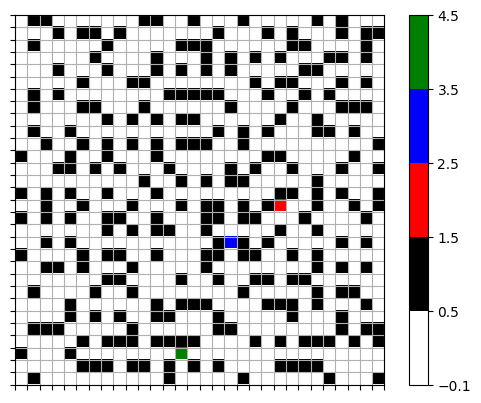

[(18, 17), (19, 17), (20, 17), (21, 17), (22, 17), (23, 17), (24, 17), (24, 18), (25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]


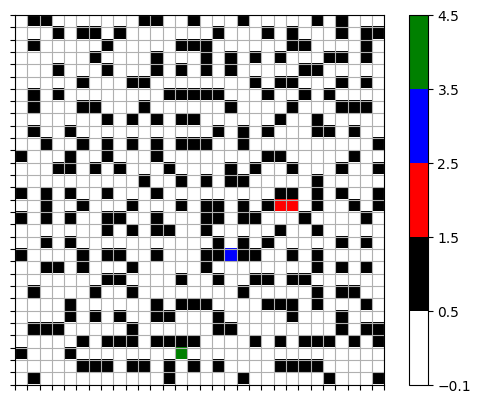

[(19, 17), (20, 17), (21, 17), (22, 17), (23, 17), (24, 17), (24, 18), (25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(20, 17), (21, 17), (22, 17), (23, 17), (24, 17), (24, 18), (25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(21, 17), (22, 17), (23, 17), (24, 17), (24, 18), (25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(22, 17), (23, 17), (24, 17), (24, 18), (25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(23, 17), (24, 17), (24, 18), (25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]


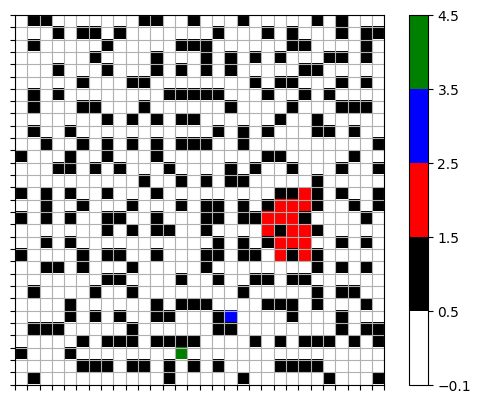

[(24, 17), (24, 18), (25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(24, 18), (25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(25, 18), (26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(26, 18), (26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(26, 17), (26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]


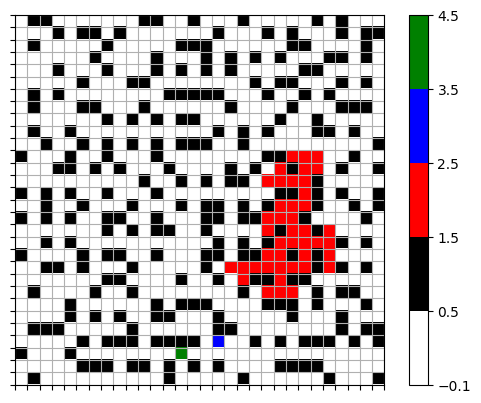

[(26, 16), (26, 15), (27, 15), (27, 14), (27, 13)]
[(26, 15), (27, 15), (27, 14), (27, 13)]
[(27, 15), (27, 14), (27, 13)]
[(27, 14), (27, 13)]


(True,
 [(18, 17),
  (19, 17),
  (20, 17),
  (21, 17),
  (22, 17),
  (23, 17),
  (24, 17),
  (24, 18),
  (25, 18),
  (26, 18),
  (26, 17),
  (26, 16),
  (26, 15),
  (27, 15),
  (27, 14),
  (27, 13)],
 14)

In [5]:
new_ship = ship.CreateShip(30)
new_ship.OpenShip()
new_ship.populateClosedCells()
new_ship.chooseInitSpawns()
new_ship.ShowShip()
new_ship.bot4(0.6)